Data Project.
Question 1

In [109]:
#The importing of the necessary libraries and setup for the API
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

#API
%pip install git+https://github.com/alemartinello/dstapi
from dstapi import DstApi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-s8i750cv
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-s8i750cv
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


1.1 The Gini coefficient and the top 10 percent share

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


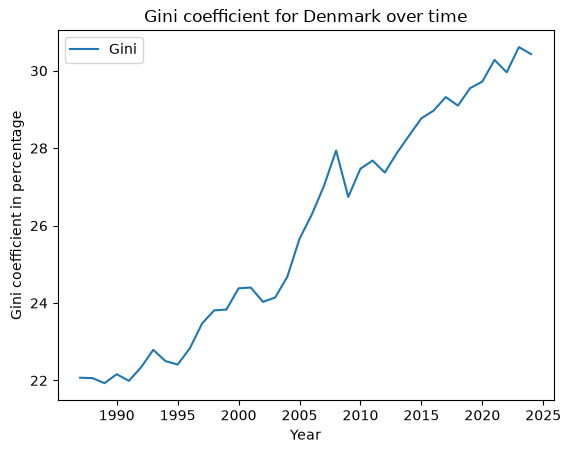

In [110]:
#importing the data from DST for IFOR41
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

#download parameters for IFOR41 data
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}
Gini = IFOR41.get_data(params=params)


#Converting the years into integers and the Gini coefficient into floats
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)

#Dropping the unnecessary columns and renaming 
Gini = Gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

Gini = Gini.rename(columns={
    'INDHOLD': 'Gini',
    'TID': 'year'
})

#Sorting the data by year and making it the index
Gini = Gini.set_index('year').sort_index()

#Figure for the Gini coefficient over time in Denmark
Gini.plot()

plt.xlabel('Year')
plt.ylabel('Gini coefficient in percentage')
plt.title('Gini coefficient for Denmark over time')
plt.show()

#Figure shows an overall increase in Gini over time, in the given period. 
#Smaller fluctuations are found around mid 1990s and mid 2000s, but the overall trend is an increase in Gini coefficient, which indicates a growing inequality in Denmark over time.


1.1 (Continued) The development in share of income held by the top 10% of the population + correlation with Gini development

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/ipykernel_9262/3190761241.py:37: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Income['DECILGEN'] = pd.Categorical(


,DECILGEN,KOMMUNEDK,TID,INDHOLD
260,First decil,All Denmark,1987,31418
261,Second decil,All Denmark,1987,59014
262,Third decil,All Denmark,1987,68786
263,Fourth decil,All Denmark,1987,77577
264,Fifth decil,All Denmark,1987,85361
...,...,...,...,...
206,Sixth decil,All Denmark,2024,311118
207,Seventh decil,All Denmark,2024,348230
209,Ninth decil,All Denmark,2024,466658
201,Tenth decil,All Denmark,2024,852980


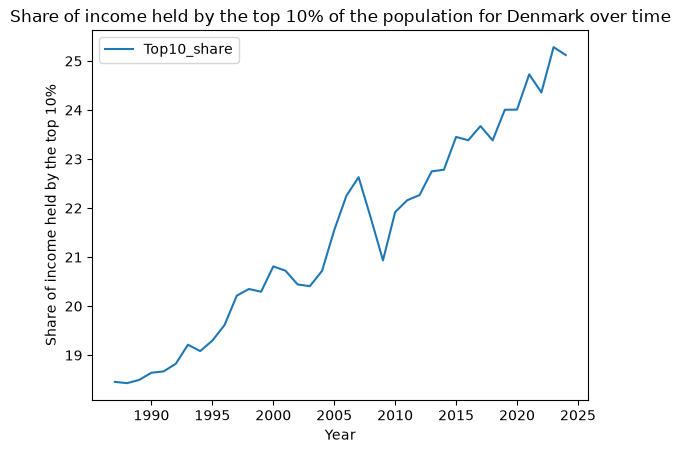

In [ ]:
#importing the data from DST IFOR32
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

#download parameters and setup/sorting for IFOR32
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

#Defining income
Income = IFOR32.get_data(params=params)


#Converting years into intergers and sorting by year and decile
Income['TID'] = Income['TID'].astype(int)
decile_order = [
    'First decil',
    'Second decil',
    'Third decil',
    'Fourth decil',
    'Fifth decil',
    'Sixth decil',
    'Seventh decil',
    'Eighth decil',
    'Ninth decil',
    'Tenth decil'
]

Income['DECILGEN'] = pd.Categorical(
    Income['DECILGEN'],
    categories=decile_order,
    ordered=True
)
Income = Income.sort_values(['TID', 'DECILGEN'])


#Checking the data, if the ordering came out right
display(Income)


#Calculating the share of income held by the top 10% of the population for each year
#The formula used is: (income of top 10% / total income)
Top10 = (
    Income.groupby('TID')
    .apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0]
           / x['INDHOLD'].sum()
    * 100)
    .reset_index(name='Top10_share')
)
Top10 = Top10.rename(columns={'TID': 'year'})

Top10.plot(x='year', y='Top10_share')

plt.title('Share of income held by the top 10% of the population for Denmark over time')
plt.xlabel('Year')
plt.ylabel('Share of income held by the top 10%')
plt.show()


0.9816415450527721


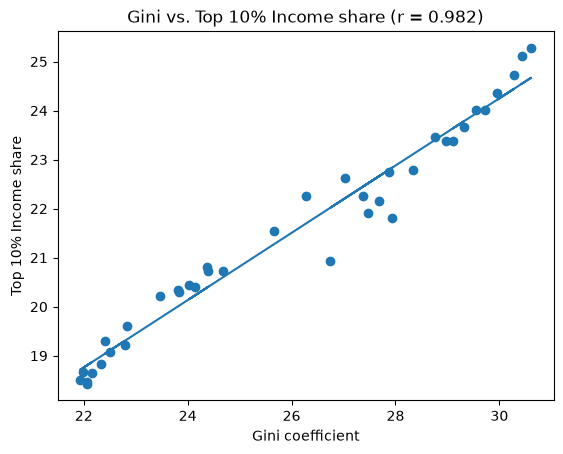

In [116]:
#Correlation between Gini and top 10% income share, plotting the results

corr = GiniTop10['Gini'].corr(GiniTop10['Top10_share'])
print(corr)

#Find trendline + scatter plot + plotting the results

x = GiniTop10['Gini']
y = GiniTop10['Top10_share'] * 100  # Convert to percentage

slope, intercept = np.polyfit(x, y, 1)

plt.scatter(x, y)

plt.plot(x, slope * x + intercept)

plt.xlabel('Gini coefficient')
plt.ylabel('Top 10% Income share')
plt.title(f'Gini vs. Top 10% Income share (r = {corr:.3f})')

plt.show()